In [6]:
# %pip install openai>=1.0 --upgrade --force-reinstall

In [14]:
# %pip install anyio distro httpx pydantic sniffio tqdm typing-extensions jupyter-server --upgrade --force-reinstall
# %pip install --force-reinstall typing-extensions==4.5
%pip install --force-reinstall openai

  Using cached openai-1.17.0-py3-none-any.whl (268 kB)
  Using cached typing_extensions-4.11.0-py3-none-any.whl (34 kB)
  Using cached distro-1.9.0-py3-none-any.whl (20 kB)
  Using cached tqdm-4.66.2-py3-none-any.whl (78 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl (10 kB)
  Using cached pydantic-2.7.0-py3-none-any.whl (407 kB)
  Using cached httpx-0.27.0-py3-none-any.whl (75 kB)
  Using cached anyio-4.3.0-py3-none-any.whl (85 kB)
  Using cached idna-3.7-py3-none-any.whl (66 kB)
  Using cached exceptiongroup-1.2.0-py3-none-any.whl (16 kB)
  Using cached certifi-2024.2.2-py3-none-any.whl (163 kB)
  Using cached httpcore-1.0.5-py3-none-any.whl (77 kB)
  Using cached h11-0.14.0-py3-none-any.whl (58 kB)
  Using cached pydantic_core-2.18.1-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (2.1 MB)
  Using cached annotated_types-0.6.0-py3-none-any.whl (12 kB)
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.11.0
    Uninstalling typin

In [1]:
%pip show openai typing-extensions

Name: openai
Version: 1.17.0
Summary: The official Python library for the openai API
Home-page: 
Author: 
Author-email: OpenAI <support@openai.com>
License: 
Location: /anaconda/envs/jupyter_env/lib/python3.8/site-packages
Requires: anyio, distro, httpx, pydantic, sniffio, tqdm, typing-extensions
Required-by: 
---
Name: typing_extensions
Version: 4.11.0
Summary: Backported and Experimental Type Hints for Python 3.8+
Home-page: 
Author: 
Author-email: "Guido van Rossum, Jukka Lehtosalo, Łukasz Langa, Michael Lee" <levkivskyi@gmail.com>
License: 
Location: /anaconda/envs/jupyter_env/lib/python3.8/site-packages
Requires: 
Required-by: annotated-types, anyio, azure-core, azure-storage-blob, ipython, openai, pydantic, pydantic_core, rich, typer
Note: you may need to restart the kernel to use updated packages.


In [11]:
#Note: The openai-python library support for Azure OpenAI is in preview.
      #Note: This code sample requires OpenAI Python library version 1.0.0 or higher.
import os
from openai import AzureOpenAI

note_text = "Contacted a patient to discuss payment options for a high deductible plan balance." # sample note text
candidate_labels = "Patient Demographics,\
Insurance Information,\
Provider Information,\
Verify Insurance Eligibility and Benefits,\
Coordination of Benefits (COB),\
Obtain Prior Authorizations,\
Medical Records,\
Itemized Bill or Charge Sheet,\
Authorization and Referral Information,\
Advance Beneficiary Notice (ABN),\
Accurate Coding,\
Claim Submission,\
Follow-up on Submitted Claims,\
Denial Management,\
Payment Posting,\
Patient Billing,\
Reconciliation,\
Reporting"

client = AzureOpenAI(
  azure_endpoint = "https://openai-bluesky-swedencentral.openai.azure.com/", 
  api_key="41f9ced454e7436cb76229c731822a05", #os.getenv("AZURE_OPENAI_KEY"),  
  api_version="2024-02-15-preview"
)


message_text = [
    {"role":"system",
    "content":"You are a revenue cycle management analyst with responsibilities for reviewing AR case processing notes and identifying the categories of actions taken."},
    {"role":"user",
    "content":f"Read the AR note below and label it with one of the following labels: {candidate_labels}\n\n## AR note text:\n{note_text}\nReturn only the category label."}
]

completion = client.chat.completions.create(
  model="gpt-4-1106", # model = "deployment_name"
  messages = message_text,
  temperature=0.7,
  max_tokens=4096,
  top_p=0.95,
  frequency_penalty=0,
  presence_penalty=0,
  stop=None
)

In [12]:
completion.choices[0].message.content

'Patient Billing'

In [16]:
import pandas as pd
import csv
import time

results = []

with open('data/sample_AR_action_notes.csv', mode='r') as csv_file:
    csv_reader = csv.reader(csv_file)
    # line_count = 0
    for i, row in enumerate(csv_reader):
        if i == 0:
            print(f'Column names are {", ".join(row)}')
        # elif i < 10:   # uncomment when testing to restrict to subset of rows
        else:           # use when iterating over all rows
            print(i)
            note_id = row[0]            # note id
            note_text = row[1]          # note text
            action_category = row[2]    # actual category
            
            # construct request
            message_text = [
                {"role":"system",
                "content":"You are a revenue cycle management analyst with responsibilities for reviewing AR case processing notes and identifying the categories of actions taken."},
                {"role":"user",
                "content":f"Read the AR note below and label it with one of the following labels: {candidate_labels}\n\n## AR note text:\n{note_text}\nReturn only the category label."}
            ]


            # call model API
            completion = client.chat.completions.create(
                model="gpt-4-1106", # model = "deployment_name"
                messages = message_text,
                temperature=0.7,
                max_tokens=4096,
                top_p=0.95,
                frequency_penalty=0,
                presence_penalty=0,
                stop=None
            )

            predicted_category = completion.choices[0].message.content
            
            # collect results in row
            results.append((note_id, note_text, action_category, predicted_category))

            time.sleep(10)


df = pd.DataFrame(results, columns=["note_id", "note_text", "action_category", "predicted_category"])


Column names are ﻿id, note, category_label  
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34


KeyboardInterrupt: 

In [17]:
df = pd.DataFrame(results, columns=["note_id", "note_text", "action_category", "predicted_category"])
df

,note_id,note_text,action_category,predicted_category
0,1,"Confirmed patient's full name, date of birth, ...",Patient Demographics,Patient Demographics
1,2,Updated patient's contact information in the s...,Patient Demographics,Patient Demographics
2,3,Verified patient demographics against the ID a...,Patient Demographics,Patient Demographics
3,4,Corrected the spelling of the patient's name t...,Patient Demographics,Patient Demographics
4,5,Added the patient's middle initial to the demo...,Patient Demographics,Patient Demographics
5,6,Recorded primary insurance details from the pa...,Insurance Information,Insurance Information
6,7,Updated the patient's insurance policy number ...,Insurance Information,Insurance Information
7,8,Added secondary insurance information for coor...,Insurance Information,Coordination of Benefits (COB)
8,9,Contacted insurance company to verify coverage...,Insurance Information,Verify Insurance Eligibility and Benefits
9,10,Scanned and uploaded a copy of the new insuran...,Insurance Information,Insurance Information


In [20]:
# calculate the accuracy
df['correct'] = df['action_category'].str.strip() == df['predicted_category'].str.strip()
accuracy = df['correct'].mean()
print(f'overall accuracy of action categorization: {accuracy:0.3f}')

overall accuracy of action categorization: 0.941


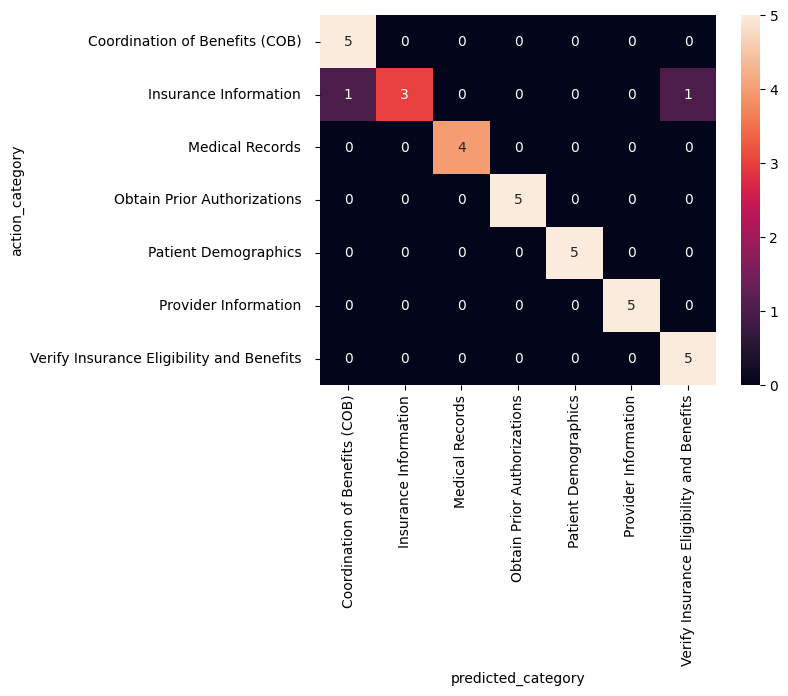

In [24]:
# construct a confusion matrix
confusion_matrix = pd.crosstab(df['action_category'], df['predicted_category'])

# visualize the confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix, annot=True, fmt='d');

In [2]:
# Request data goes here
# The example below assumes JSON formatting which may be updated
# depending on the format your endpoint expects.
# check the test tab in the endpoint interface for a link to API input schema
# More information can be found here:
# https://docs.microsoft.com/azure/machine-learning/how-to-deploy-advanced-entry-script
data = {
    "input_data": {
        "input_string": [
            {
                "role": "user",
                "content": "I am going to Paris, what should I see?"
            },
            {
                "role": "assistant",
                "content": "Paris, the capital of France, is known for its stunning architecture, art museums, historical landmarks, and romantic atmosphere. Here are some of the top attractions to see in Paris:\n\n1. The Eiffel Tower: The iconic Eiffel Tower is one of the most recognizable landmarks in the world and offers breathtaking views of the city.\n2. The Louvre Museum: The Louvre is one of the world's largest and most famous museums, housing an impressive collection of art and artifacts, including the Mona Lisa.\n3. Notre-Dame Cathedral: This beautiful cathedral is one of the most famous landmarks in Paris and is known for its Gothic architecture and stunning stained glass windows.\n\nThese are just a few of the many attractions that Paris has to offer. With so much to see and do, it's no wonder that Paris is one of the most popular tourist destinations in the world."
            },
            {
                "role": "user",
                "content": "What is so great about #1?"
            }
        ],
        "parameters": {
            "temperature": 0.6,
            "top_p": 0.9,
            "do_sample": True,
            "max_new_tokens": 200,
            "return_full_text": False
        }
    }
}

body = str.encode(json.dumps(data))


In [3]:
req = urllib.request.Request(url, body, headers)

try:
    response = urllib.request.urlopen(req)

    result = response.read()
    print(result)
except urllib.error.HTTPError as error:
    print("The request failed with status code: " + str(error.code))

    # Print the headers - they include the requert ID and the timestamp, which are useful for debugging the failure
    print(error.info())
    print(error.read().decode("utf8", 'ignore'))

b'{"output":" The Eiffel Tower is a symbol of Paris and France, and is considered an engineering marvel. It was built between 1887 and 1889 as the entrance arch to the 1889 Exposition Universelle (World\'s Fair) and was originally criticized by some of France\'s leading artists and intellectuals for its design. However, it quickly became a beloved symbol of Paris and France, and today it is visited by millions of tourists every year.\\n\\nOne of the things that makes the Eiffel Tower so great is its impressive size and structure. It stands at over 320 meters (1,050 feet) tall, making it one of the tallest structures in Paris. The tower is made of iron and consists of four pillars that support the four corners of a large square platform. The tower is also famous for its three levels, which offer stunning views of Paris and the surrounding area. Visitors can"}'


In [14]:
# Request data goes here
# The example below assumes JSON formatting which may be updated
# depending on the format your endpoint expects.
# More information can be found here:
# https://docs.microsoft.com/azure/machine-learning/how-to-deploy-advanced-entry-script
data = {
    "input_data": {
        "input_string": [
            {
                "role": "user",
                "content": "What are some common failure modes for pumps? Return your response as JSON."
            }
        ],
        "parameters": {
            "temperature": 0.6,
            "top_p": 0.9,
            "do_sample": True,
            "max_new_tokens": 1000,
            "return_full_text": False
        }
    }
}

body = str.encode(json.dumps(data))


In [15]:
req = urllib.request.Request(url, body, headers)

try:
    response = urllib.request.urlopen(req)

    result = response.read()
    print(result)
except urllib.error.HTTPError as error:
    print("The request failed with status code: " + str(error.code))

    # Print the headers - they include the requert ID and the timestamp, which are useful for debugging the failure
    print(error.info())
    print(error.read().decode("utf8", 'ignore'))

b'{"output":" {\\n\\n\\"failure_modes\\": [\\n  {\\n    \\"name\\": \\"Mechanical Seal Failure\\",\\n    \\"description\\": \\"Mechanical seals are used to prevent leakage between the pump chamber and the environment. Failure of the mechanical seal can lead to significant leaks, resulting in downtime and potential environmental damage.\\",\\n    \\"symptoms\\": [\\"Leaking around the seal area\\", \\"Increased vibration\\", \\"Decreased pump performance\\"]\\n  },\\n  {\\n    \\"name\\": \\"Impeller Damage\\",\\n    \\"description\\": \\"Impellers are responsible for moving fluid through the pump. Damage to the impeller can result in reduced pump performance or complete failure.\\",\\n    \\"symptoms\\": [\\"Decreased flow rate\\", \\"Increased vibration\\", \\"Loud noises during operation\\"]\\n  },\\n  {\\n    \\"name\\": \\"Bearing Failure\\",\\n    \\"description\\": \\"Bearings support the rotating parts of the pump and allow for smooth operation. Failure of the bearings can resul

In [17]:
json.loads(json.loads(result)['output'])

{'failure_modes': [{'name': 'Mechanical Seal Failure',
   'description': 'Mechanical seals are used to prevent leakage between the pump chamber and the environment. Failure of the mechanical seal can lead to significant leaks, resulting in downtime and potential environmental damage.',
   'symptoms': ['Leaking around the seal area',
    'Increased vibration',
    'Decreased pump performance']},
  {'name': 'Impeller Damage',
   'description': 'Impellers are responsible for moving fluid through the pump. Damage to the impeller can result in reduced pump performance or complete failure.',
   'symptoms': ['Decreased flow rate',
    'Increased vibration',
    'Loud noises during operation']},
  {'name': 'Bearing Failure',
   'description': 'Bearings support the rotating parts of the pump and allow for smooth operation. Failure of the bearings can result in increased vibration and eventual pump failure.',
   'symptoms': ['Increased vibration',
    'Loud noises during operation',
    'Decreas

In [18]:
[d['name'] for d in json.loads(json.loads(result)['output'])['failure_modes']]

['Mechanical Seal Failure',
 'Impeller Damage',
 'Bearing Failure',
 'Cavitation',
 'Wear and Tear',
 'Foreign Object Damage',
 'Electrical Failure']

In [20]:
# Request data goes here
# The example below assumes JSON formatting which may be updated
# depending on the format your endpoint expects.
# More information can be found here:
# https://docs.microsoft.com/azure/machine-learning/how-to-deploy-advanced-entry-script

candidate_labels = "thrust bearings issue, pump seal leak, broken breaker, pipe leak, check valve broken"

wo_long_text = """P-5270A high vibrations 12.02.2021 19:59:57 UTC R_MSD365 MS Dynamics 365 (R_MSD365) Notification description: Vibration technician found P-5270A vibrating more than usual. Mechanical notified operations and the pump was swapped to P-5270B 02/18/2021 08:50:09 UTC Dwayne Greenlee (USDGRL) After looking at SKF it looks as though we have an issue with the thrust bearings. The pump needs to be pulled and repaired according to the MRS card
"""
wo_long_text = wo_long_text.replace('\r\n',' ')

user_content = f"Read the Work Order below and label it with one of the following labels: {candidate_labels}\n\n## Work Order:\n{wo_long_text}"

print(user_content)



Read the Work Order below and label it with one of the following labels: thrust bearings issue, pump seal leak, broken breaker, pipe leak, check valve broken

## Work Order:
P-5270A high vibrations 12.02.2021 19:59:57 UTC R_MSD365 MS Dynamics 365 (R_MSD365) Notification description: Vibration technician found P-5270A vibrating more than usual. Mechanical notified operations and the pump was swapped to P-5270B 02/18/2021 08:50:09 UTC Dwayne Greenlee (USDGRL) After looking at SKF it looks as though we have an issue with the thrust bearings. The pump needs to be pulled and repaired according to the MRS card



In [21]:
data = {
    "input_data": {
        "input_string": [
            {
                "role": "user",
                "content": user_content
            }
        ],
        "parameters": {
            "temperature": 0.6,
            "top_p": 0.9,
            "do_sample": True,
            "max_new_tokens": 1000,
            "return_full_text": False
        }
    }
}

body = str.encode(json.dumps(data))

In [22]:
req = urllib.request.Request(url, body, headers)

try:
    response = urllib.request.urlopen(req)

    result = response.read()
    print(result)
except urllib.error.HTTPError as error:
    print("The request failed with status code: " + str(error.code))

    # Print the headers - they include the requert ID and the timestamp, which are useful for debugging the failure
    print(error.info())
    print(error.read().decode("utf8", 'ignore'))

b'{"output":" Thrust bearings issue."}'


In [23]:
json.loads(result)['output']

' Thrust bearings issue.'

### Iterate over rows

In [4]:
def construct_user_content_request_body(wo_text, candidate_labels):
    wo_text = wo_text.replace('\r\n',' ')

    user_content = f"Read the Work Order below and label it with one of the following labels: {candidate_labels}\n\n## Work Order:\n{wo_long_text}"

    data = {
        "input_data": {
            "input_string": [
                {
                    "role": "user",
                    "content": user_content
                }
            ],
            "parameters": {
                "temperature": 0.6,
                "top_p": 0.9,
                "do_sample": True,
                "max_new_tokens": 1000,
                "return_full_text": False
            }
        }
    }

    body = str.encode(json.dumps(data))
    
    return body

In [6]:
candidate_labels = "thrust bearings issue, pump seal leak, broken breaker, pipe leak, check valve broken"

import csv
import pandas as pd

results = []

with open('data/sample_data.csv', mode='r') as csv_file:
    csv_reader = csv.reader(csv_file)
    # line_count = 0
    for i, row in enumerate(csv_reader):
        if i == 0:
            print(f'Column names are {", ".join(row)}')
        elif i < 10:   
            print(i)
            wo_desc = row[0]
            wo_long_text = row[1] # long text description
            failure_mode = row[2]
            # construct request
            body = construct_user_content_request_body(wo_long_text, candidate_labels)
            req = urllib.request.Request(url, body, headers)

            # call model API
            try:
                response = urllib.request.urlopen(req, timeout=10)

                result = response.read()
                predicted_fm = json.loads(result)['output']
                # collect results in row
                results.append((wo_desc, failure_mode, predicted_fm))

            except urllib.error.HTTPError as error:
                print("The request failed with status code: " + str(error.code))

                # Print the headers - they include the requert ID and the timestamp, which are useful for debugging the failure
                print(error.info())
                print(error.read().decode("utf8", 'ignore'))
        else:
            pass

df = pd.DataFrame(results, columns=['WO_Desc','failure_mode_actual','failure_mode_predicted'])


Column names are ﻿Short Description, Long Text Description, Failure Mode Category  
1
2
3
4
5
6
7
8
9


In [7]:
df

,WO_Desc,failure_mode_actual,failure_mode_predicted
0,P-5270A high vibrations,thrust bearings issue,Thrust bearings issue.
1,P-6336A MVR W-438 pump seal leak,pump seal leak,Label: pump seal leak
2,P-5470(D) OIL LEAK ON PIPING TO BEARINGS,pipe leak,pipe leak
3,BKR-221D tripping intermittently,broken breaker,broken breaker.
4,T-1003A steam leak detected,pipe leak,pipe leak
5,CHK-5573 not closing properly,check valve broken,check valve issue.
6,V-4022 abnormal noise,thrust bearings issue,Thrust bearings issue.
7,P-2105B seal failure observed,pump seal leak,Pump seal leak.
8,Pipe L-1010 corrosion hole,pipe leak,pipe leak
